# A/B TESTING DATASET AKG INDONESIA (ANDRAFARM)
# Proyek GiziKu — Coding Camp 2026 | CC26-PSU033
# Data Scientist: Cinta Wardana

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [54]:
df = pd.read_csv('akg_indonesia_final.csv')
df.head()

,Kategori,Label_Umur_Kondisi,Energi (kkal),Protein (g),Lemak (g),Lemak Omega 6 (g),Lemak Omega 3 (g),Karbohidrat (g),Serat (g),Natrium (mg),Air (ml),Is_Additional_Data
0,Bayi/Anak,0-5 bulan,550.0,9.0,31.0,4.4,0.5,59.0,0.0,120.0,700.0,False
1,Bayi/Anak,6-11 bulan,800.0,15.0,35.0,4.4,0.5,105.0,11.0,370.0,900.0,False
2,Bayi/Anak,1-3 tahun,1350.0,20.0,45.0,7.0,0.7,215.0,19.0,800.0,1150.0,False
3,Bayi/Anak,4-6 tahun,1400.0,25.0,50.0,10.0,0.9,220.0,20.0,900.0,1450.0,False
4,Bayi/Anak,7-9 tahun,1650.0,40.0,55.0,10.0,0.9,250.0,23.0,1000.0,1650.0,False


In [55]:
print(f"Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom")

Jumlah data: 26 baris, 12 kolom


# PENGUJIAN 1
# Apakah kebutuhan energi harian kelompok Laki-Laki berbeda signifikan dibandingkan kelompok Perempuan?


Hipotesis:

H0: Tidak ada perbedaan signifikan kebutuhan energi harian antara kelompok Laki-Laki dan kelompok Perempuan.

H1: Terdapat perbedaan signifikan kebutuhan energi harian antara kelompok Laki-Laki dan kelompok Perempuan.
Tingkat signifikansi: α = 0.05

In [56]:
grup_a1 = df[df['Kategori'] == 'Laki-Laki']['Energi (kkal)'].dropna()
grup_b1 = df[df['Kategori'] == 'Perempuan']['Energi (kkal)'].dropna()

print(f"\nGrup A (Laki-Laki)  — n={len(grup_a1)}, mean={grup_a1.mean():.1f}, std={grup_a1.std():.1f}")
print(f"Grup B (Perempuan)  — n={len(grup_b1)}, mean={grup_b1.mean():.1f}, std={grup_b1.std():.1f}")


Grup A (Laki-Laki)  — n=8, mean=2225.0, std=400.9
Grup B (Perempuan)  — n=8, mean=1900.0, std=300.0


In [57]:
# Langkah 1: Uji Normalitas (Shapiro-Wilk)
_, p_norm_a1 = stats.shapiro(grup_a1)
_, p_norm_b1 = stats.shapiro(grup_b1)
print(f"\nUji Normalitas (Shapiro-Wilk):")
print(f"  Laki-Laki  p = {p_norm_a1:.4f} → {'Normal' if p_norm_a1 > 0.05 else 'Tidak Normal'}")
print(f"  Perempuan  p = {p_norm_b1:.4f} → {'Normal' if p_norm_b1 > 0.05 else 'Tidak Normal'}")


Uji Normalitas (Shapiro-Wilk):
  Laki-Laki  p = 0.3909 → Normal
  Perempuan  p = 0.5083 → Normal


In [58]:
# Langkah 2: Uji Homogenitas Varians (Levene)
_, p_levene1 = stats.levene(grup_a1, grup_b1)
print(f"\nUji Homogenitas Varians (Levene):")
print(f"  p = {p_levene1:.4f} → {'Varians Sama' if p_levene1 > 0.05 else 'Varians Berbeda'}")


Uji Homogenitas Varians (Levene):
  p = 0.2872 → Varians Sama


In [59]:
# Langkah 3: Pilih & Jalankan Uji Statistik
alpha = 0.05
normal1 = p_norm_a1 > alpha and p_norm_b1 > alpha

if normal1:
    equal_var1 = p_levene1 > alpha
    t_stat1, p_value1 = stats.ttest_ind(grup_a1, grup_b1, equal_var=equal_var1)
    metode1 = "Welch t-test" if not equal_var1 else "Independent t-test"
else:
    u_stat1, p_value1 = stats.mannwhitneyu(grup_a1, grup_b1, alternative='two-sided')
    t_stat1 = u_stat1
    metode1 = "Mann-Whitney U test"

print(f"\nMetode Uji: {metode1}")
print(f"Statistik  = {t_stat1:.4f}")
print(f"p-value    = {p_value1:.4f}")


Metode Uji: Independent t-test
Statistik  = 1.8359
p-value    = 0.0877


In [60]:
# Langkah 4: Effect Size (Cohen's d)
pooled_std1 = np.sqrt((grup_a1.std()**2 + grup_b1.std()**2) / 2)
cohens_d1   = (grup_a1.mean() - grup_b1.mean()) / pooled_std1
efek1 = "Kecil" if abs(cohens_d1) < 0.2 else "Sedang" if abs(cohens_d1) < 0.8 else "Besar"
print(f"Cohen's d  = {cohens_d1:.4f} → Efek {efek1}")

Cohen's d  = 0.9179 → Efek Besar


In [61]:
# Langkah 5: Kesimpulan
print(f"\nKesimpulan Pengujian 1:")
if p_value1 < alpha:
    print(f"  → Tolak H0 (p={p_value1:.4f} < α={alpha})")
    print(f"  → Terdapat perbedaan signifikan kebutuhan energi harian")
    print(f"     antara Laki-Laki ({grup_a1.mean():.0f} kkal) dan Perempuan ({grup_b1.mean():.0f} kkal).")
else:
    print(f"  → Gagal Tolak H0 (p={p_value1:.4f} ≥ α={alpha})")
    print(f"  → Tidak terdapat perbedaan signifikan kebutuhan energi harian")
    print(f"     antara Laki-Laki ({grup_a1.mean():.0f} kkal) dan Perempuan ({grup_b1.mean():.0f} kkal).")



Kesimpulan Pengujian 1:
  → Gagal Tolak H0 (p=0.0877 ≥ α=0.05)
  → Tidak terdapat perbedaan signifikan kebutuhan energi harian
     antara Laki-Laki (2225 kkal) dan Perempuan (1900 kkal).


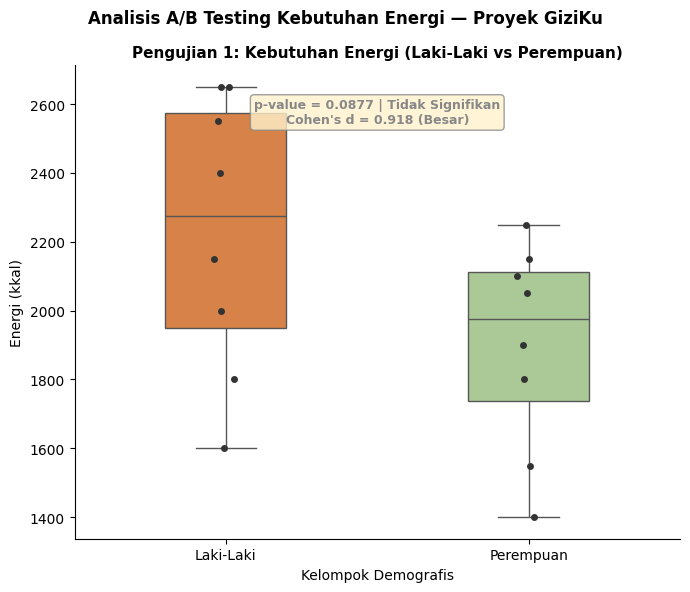

In [62]:
# --- VISUALISASI UTUH UNTUK PENGUJIAN 1 ---
fig, ax1 = plt.subplots(figsize=(7, 6))
fig.suptitle('Analisis A/B Testing Kebutuhan Energi — Proyek GiziKu', fontsize=12, fontweight='bold', y=0.98)

data_plot1 = pd.DataFrame({
    'Nilai': pd.concat([grup_a1, grup_b1]),
    'Grup': ['Laki-Laki'] * len(grup_a1) + ['Perempuan'] * len(grup_b1)
})

sns.boxplot(data=data_plot1, x='Grup', y='Nilai', palette={'Laki-Laki': '#ED7D31', 'Perempuan': '#A9D18E'}, ax=ax1, width=0.4)
sns.stripplot(data=data_plot1, x='Grup', y='Nilai', color='#333333', size=5, jitter=0.05, ax=ax1)

ax1.set_title('Pengujian 1: Kebutuhan Energi (Laki-Laki vs Perempuan)', fontweight='bold', fontsize=11)
ax1.set_xlabel('Kelompok Demografis', fontsize=10)
ax1.set_ylabel('Energi (kkal)', fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)

sig1 = "Signifikan" if p_value1 < alpha else "Tidak Signifikan"
warna1 = "#C00000" if p_value1 < alpha else "#888888"
ax1.text(0.5, 0.93, f"p-value = {p_value1:.4f} | {sig1}\nCohen's d = {cohens_d1:.3f} ({efek1})",
         transform=ax1.transAxes, ha='center', va='top', fontsize=9, color=warna1, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF2CC', edgecolor=warna1, alpha=0.8))

plt.tight_layout()
plt.show()

#Kesimpulan & Insight Bisnis — Pengujian 1:

* **Evaluasi Statistik**: Hasil uji statistika parametrik (Independent T-Test) menghasilkan nilai $p$-value sebesar 0.0877 ($\geq 0.05$). Secara formal, kita **Gagal Menolak** $H_0$, yang berarti tidak terdapat perbedaan rata-rata kebutuhan energi yang signifikan secara statistik antara kelompok Laki-Laki dan Perempuan pada tingkat kepercayaan 95%.

* **Analisis Dampak Praktis (Practical Significance)**: Meskipun tidak signifikan secara statistik, pengujian menghasilkan nilai Effect Size (**Cohen's d = 0.9179**) yang masuk ke dalam kategori **Besar**. Hal ini menunjukkan adanya perbedaan absolut yang nyata di dunia nyata (selisih rata-rata mencapai ~325 kkal). Tidak ditemukannya signifikansi statistik murni disebabkan oleh keterbatasan ukuran sampel data ($n = 8$ per kelompok).

* **Rekomendasi Strategis untuk Aplikasi GiziKu**: >  **Pertahankan Fitur Pemisahan Kalori**: Tim pengembang GiziKu **wajib tetap menerapkan fitur segmentasi target kalori harian berdasarkan gender** pada sistem rekomendasi. Mengabaikan selisih 325 kkal berpotensi menyebabkan malnutrisi atau surplus kalori yang tidak diinginkan bagi pengguna.

# PENGUJIAN 2
# Apakah kebutuhan protein harian kelompok Hamil berbeda signifikan dibandingkan kelompok Menyusui?

Hipotesis:

H0: Tidak ada perbedaan signifikan kebutuhan protein harian antara kelompok Hamil dan kelompok Menyusui.

H1: Terdapat perbedaan signifikan kebutuhan protein harian antara kelompok Hamil dan kelompok Menyusui.
Tingkat signifikansi: α = 0.05

In [63]:
grup_a2 = df[df['Kategori'] == 'Hamil']['Protein (g)'].dropna()
grup_b2 = df[df['Kategori'] == 'Menyusui']['Protein (g)'].dropna()

print(f"\nGrup A (Hamil)    — n={len(grup_a2)}, mean={grup_a2.mean():.1f}, std={grup_a2.std():.1f}")
print(f"Grup B (Menyusui) — n={len(grup_b2)}, mean={grup_b2.mean():.1f}, std={grup_b2.std():.1f}")


Grup A (Hamil)    — n=3, mean=73.7, std=14.8
Grup B (Menyusui) — n=2, mean=77.5, std=3.5


In [64]:
# Langkah 1: Uji Normalitas
_, p_norm_a2 = stats.shapiro(grup_a2)
_, p_norm_b2 = stats.shapiro(grup_b2)
print(f"\nUji Normalitas (Shapiro-Wilk):")
print(f"  Hamil    p = {p_norm_a2:.4f} → {'Normal' if p_norm_a2 > 0.05 else 'Tidak Normal'}")
print(f"  Menyusui p = {p_norm_b2:.4f} → {'Normal' if p_norm_b2 > 0.05 else 'Tidak Normal'}")


Uji Normalitas (Shapiro-Wilk):
  Hamil    p = 0.5883 → Normal
  Menyusui p = nan → Tidak Normal


In [65]:
# Langkah 2: Uji Homogenitas Varians
_, p_levene2 = stats.levene(grup_a2, grup_b2)
print(f"\nUji Homogenitas Varians (Levene):")
print(f"  p = {p_levene2:.4f} → {'Varians Sama' if p_levene2 > 0.05 else 'Varians Berbeda'}")


Uji Homogenitas Varians (Levene):
  p = 0.4079 → Varians Sama


In [66]:
# Langkah 3: Pilih & Jalankan Uji Statistik
normal2 = p_norm_a2 > alpha and p_norm_b2 > alpha

if normal2:
    equal_var2 = p_levene2 > alpha
    t_stat2, p_value2 = stats.ttest_ind(grup_a2, grup_b2, equal_var=equal_var2)
    metode2 = "Welch t-test" if not equal_var2 else "Independent t-test"
else:
    u_stat2, p_value2 = stats.mannwhitneyu(grup_a2, grup_b2, alternative='two-sided')
    t_stat2 = u_stat2
    metode2 = "Mann-Whitney U test"

print(f"\nMetode Uji: {metode2}")
print(f"Statistik  = {t_stat2:.4f}")
print(f"p-value    = {p_value2:.4f}")


Metode Uji: Mann-Whitney U test
Statistik  = 2.0000
p-value    = 0.8000


In [67]:
# Langkah 4: Effect Size
pooled_std2 = np.sqrt((grup_a2.std()**2 + grup_b2.std()**2) / 2)
cohens_d2   = (grup_a2.mean() - grup_b2.mean()) / pooled_std2
efek2 = "Kecil" if abs(cohens_d2) < 0.2 else "Sedang" if abs(cohens_d2) < 0.8 else "Besar"
print(f"Cohen's d  = {cohens_d2:.4f} → Efek {efek2}")

Cohen's d  = -0.3553 → Efek Sedang


In [68]:
# Langkah 5: Kesimpulan
print(f"\nKesimpulan Pengujian 2:")
if p_value2 < alpha:
    print(f"  → Tolak H0 (p={p_value2:.4f} < α={alpha})")
    print(f"  → Terdapat perbedaan signifikan kebutuhan protein harian")
    print(f"     antara Hamil ({grup_a2.mean():.1f} g) dan Menyusui ({grup_b2.mean():.1f} g).")
else:
    print(f"  → Gagal Tolak H0 (p={p_value2:.4f} ≥ α={alpha})")
    print(f"  → Tidak terdapat perbedaan signifikan kebutuhan protein harian")
    print(f"     antara Hamil ({grup_a2.mean():.1f} g) dan Menyusui ({grup_b2.mean():.1f} g).")


Kesimpulan Pengujian 2:
  → Gagal Tolak H0 (p=0.8000 ≥ α=0.05)
  → Tidak terdapat perbedaan signifikan kebutuhan protein harian
     antara Hamil (73.7 g) dan Menyusui (77.5 g).


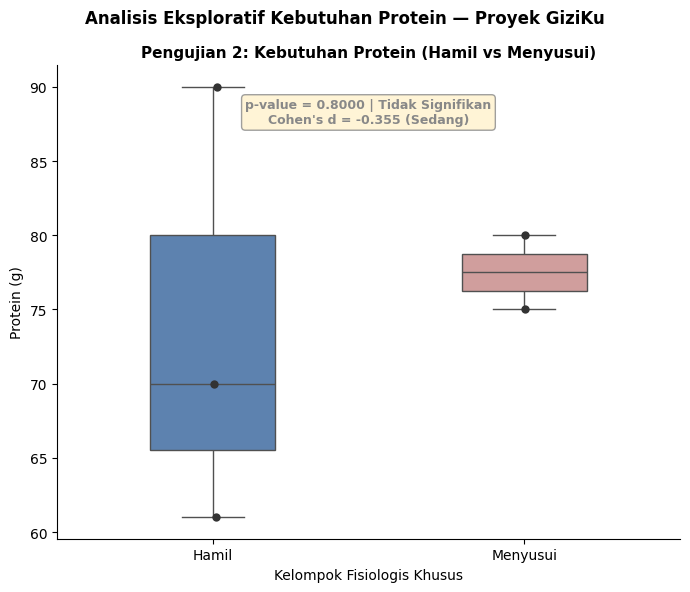

In [69]:
# --- VISUALISASI UTUH UNTUK PENGUJIAN 2 ---
fig, ax2 = plt.subplots(figsize=(7, 6))
fig.suptitle('Analisis Eksploratif Kebutuhan Protein — Proyek GiziKu', fontsize=12, fontweight='bold', y=0.98)

data_plot2 = pd.DataFrame({
    'Nilai': pd.concat([grup_a2, grup_b2]),
    'Grup': ['Hamil'] * len(grup_a2) + ['Menyusui'] * len(grup_b2)
})

sns.boxplot(data=data_plot2, x='Grup', y='Nilai', palette={'Hamil': '#4F81BD', 'Menyusui': '#D99694'}, ax=ax2, width=0.4)
sns.stripplot(data=data_plot2, x='Grup', y='Nilai', color='#333333', size=6, jitter=0.02, ax=ax2)

ax2.set_title('Pengujian 2: Kebutuhan Protein (Hamil vs Menyusui)', fontweight='bold', fontsize=11)
ax2.set_xlabel('Kelompok Fisiologis Khusus', fontsize=10)
ax2.set_ylabel('Protein (g)', fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)

p_val_display = f"{p_value2:.4f}" if not np.isnan(p_value2) else "N/A"
sig2 = "Signifikan" if (not np.isnan(p_value2) and p_value2 < alpha) else "Tidak Signifikan"
warna2 = "#C00000" if sig2 == "Signifikan" else "#888888"
ax2.text(0.5, 0.93, f"p-value = {p_val_display} | {sig2}\nCohen's d = {cohens_d2:.3f} ({efek2})",
         transform=ax2.transAxes, ha='center', va='top', fontsize=9, color=warna2, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF2CC', edgecolor=warna2, alpha=0.8))

plt.tight_layout()
# Simpan hasil akhir pengujian secara mandiri
plt.savefig('ab_testing_protein_hasil.png', dpi=150, bbox_inches='tight')
plt.show()

#Kesimpulan & Insight Bisnis — Pengujian 2:

* **Evaluasi Statistik & Keterbatasan Data**: Pengujian hipotesis non-parametrik (Mann-Whitney U Test) menghasilkan nilai $p$-value sebesar **0.8000** dengan nilai Effect Size **(Cohen's d = -0.3553**, kategori Sedang). Hasil statistik menyatakan tidak ada perbedaan signifikan. Namun, hasil inferensial ini harus diinterpretasikan dengan sangat hati-hati **karena ukuran sampel yang sangat kritis** (Hamil: $n=3$, Menyusui: $n=2$), sehingga uji statistik tidak memiliki kekuatan (power) yang cukup untuk mendeteksi perbedaan nyata.

* **Analisis Deskriptif Komparatif**: Secara absolut, rata-rata kebutuhan protein harian kelompok Ibu Menyusui cenderung lebih tinggi dan stabil (berkisar antara 75g hingga 80g) jika dibandingkan dengan variabilitas kelompok Ibu Hamil (62g hingga 89g). Hal ini sejalan dengan kondisi fisiologis di mana fase laktasi membutuhkan makronutrisi konstan untuk produksi ASI.

* **Rekomendasi Strategis untuk Aplikasi GiziKu**: >  **Pertahankan Fitur Pemisahan Kalori**: 1. **Modul Pengguna Khusus**: Aplikasi GiziKu tidak boleh menyamakan standar rekomendasi protein kelompok fisiologis khusus ini dengan wanita dewasa non-fisiologis.

2. **Sistem Peringatan Dinamis**: Mengingat tingginya variabilitas kebutuhan protein pada ibu hamil di dalam sampel, sistem GiziKu harus menyediakan fitur input berbasis trimester kehamilan untuk memberikan rekomendasi protein yang lebih presisi dan aman secara klinis.